In [4]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

# Qiskit imports
from qiskit import transpile
from qiskit.circuit.library import ZZFeatureMap
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import SamplerV2 as AerSampler
from qiskit_machine_learning.kernels import FidelityQuantumKernel, TrainableFidelityQuantumKernel
from qiskit_algorithms.state_fidelities import ComputeUncompute

# load dataset
csv_path = "ClaMP_Raw-5184.csv" 
df = pd.read_csv(csv_path)

df.head()

ModuleNotFoundError: No module named 'pandas'

In [ ]:
# shape of data
print(df.shape)

# dataset info
df.info()

(5184, 56)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5184 entries, 0 to 5183
Data columns (total 56 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   e_magic                      5184 non-null   int64  
 1   e_cblp                       5184 non-null   int64  
 2   e_cp                         5184 non-null   int64  
 3   e_crlc                       5184 non-null   int64  
 4   e_cparhdr                    5184 non-null   int64  
 5   e_minalloc                   5184 non-null   int64  
 6   e_maxalloc                   5184 non-null   int64  
 7   e_ss                         5184 non-null   int64  
 8   e_sp                         5184 non-null   int64  
 9   e_csum                       5184 non-null   int64  
 10  e_ip                         5184 non-null   int64  
 11  e_cs                         5184 non-null   int64  
 12  e_lfarlc                     5184 non-null   int64  
 13  e_ovno 

In [ ]:
# The features for CLaMP 
clamp_features = [
    'NumberOfSections', 'Characteristics', 'Magic', 'MajorLinkerVersion',
    'SizeOfCode', 'AddressOfEntryPoint', 'ImageBase', 'SizeOfImage',
    'DllCharacteristics', 'SizeOfStackReserve'
]

# features, x 
# ground truth target labels, y
x = df[clamp_features]
y = df['class']

print("Shape:")
print(f"x shape: {x.shape}")
print(f"y shape: {y.shape}")

print("\nHead:")
print(y.head())

Shape:
x shape: (5184, 10)
y shape: (5184,)

Head:
0    0
1    0
2    0
3    0
4    0
Name: class, dtype: int64


In [ ]:
# Split data
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=10, stratify=y
)

print(f"len(x_train): {len(x_train)}")
print(f"len(x_test):  {len(x_test)}")
print(f"x_train.shape: {x_train.shape}")
print(f"x_test.shape:  {x_test.shape}")
print(f"y_train.shape: {y_train.shape}")
print(f"y_test.shape:  {y_test.shape}")

len(x_train): 4147
len(x_test):  1037
x_train.shape: (4147, 10)
x_test.shape:  (1037, 10)
y_train.shape: (4147,)
y_test.shape:  (1037,)


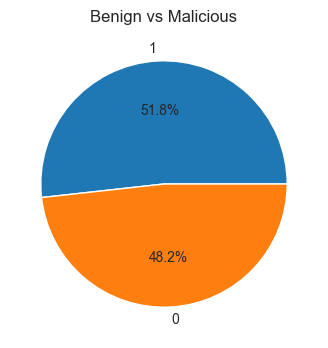

In [ ]:
#Pie Chart
sns.set_style('whitegrid') 
plt.figure(figsize=(6, 4)) 
plt.pie(df['class'].value_counts(), labels=df['class'].value_counts().index, autopct='%1.1f%%')
plt.title('Benign vs Malicious')
plt.show()

In [ ]:
# Feature Scaling
scaler = MinMaxScaler(feature_range=(0, 1))
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print(f"Scaled Train Bounds: Min={x_train_scaled.min():.1f}, Max={x_train_scaled.max():.1f}")

Scaled Train Bounds: Min=0.0, Max=1.0


In [ ]:
# Simulator subset (larger — cheap to run locally, no queue/cost)
sim_train_size = 500
sim_test_size = 150

# Real-hardware subset (small — keeps hardware queue time/cost down)
hw_train_size = 20
hw_test_size = 10

np.random.seed(42)
sim_train_indices = np.random.choice(len(x_train_scaled), sim_train_size, replace=False)
sim_test_indices = np.random.choice(len(x_test_scaled), sim_test_size, replace=False)
hw_train_indices = np.random.choice(len(x_train_scaled), hw_train_size, replace=False)
hw_test_indices = np.random.choice(len(x_test_scaled), hw_test_size, replace=False)

# Simulator downsample
x_train_scaled_sim = x_train_scaled[sim_train_indices]
x_test_scaled_sim = x_test_scaled[sim_test_indices]
y_train_sim = y_train.iloc[sim_train_indices]
y_test_sim = y_test.iloc[sim_test_indices]

# Hardware downsample
x_train_scaled_hw = x_train_scaled[hw_train_indices]
x_test_scaled_hw = x_test_scaled[hw_test_indices]
y_train_hw = y_train.iloc[hw_train_indices]
y_test_hw = y_test.iloc[hw_test_indices]

print(f"Simulator Dimensions -> Train: {x_train_scaled_sim.shape}, Test: {x_test_scaled_sim.shape}")
print(f"Hardware Dimensions  -> Train: {x_train_scaled_hw.shape}, Test: {x_test_scaled_hw.shape}")

In [ ]:
# Map the simulator subset
qX_train_sim = x_train_scaled_sim
qX_test_sim = x_test_scaled_sim
qy_train_sim = y_train_sim.values
qy_test_sim = y_test_sim.values

# creating the feature map (same circuit is reused for the hardware kernel below)
num_qubits = qX_train_sim.shape[1]
feature_map = ZZFeatureMap(feature_dimension=num_qubits, reps=2,
                           entanglement='linear')

# -------------- Local Simulator Backend ------------------------

sim_sampler = AerSampler()
sim_sampler.options.default_shots = 1024
sim_fidelity = ComputeUncompute(sampler=sim_sampler)
sim_quantum_kernel = FidelityQuantumKernel(feature_map=feature_map,
                                           fidelity=sim_fidelity)

feature_map.decompose().draw('mpl')

In [ ]:
n_tr, n_te = len(qX_train_sim), len(qX_test_sim)
print(f"[Simulator] circuits: {n_tr*(n_tr-1)//2} train + {n_te*n_tr} test")

K_train_sim = sim_quantum_kernel.evaluate(qX_train_sim)
K_test_sim  = sim_quantum_kernel.evaluate(qX_test_sim, qX_train_sim)

qsvm_model_sim = SVC(kernel='precomputed', C=1.0)
qsvm_model_sim.fit(K_train_sim, qy_train_sim)

y_pred_sim  = qsvm_model_sim.predict(K_test_sim)
y_score_sim = qsvm_model_sim.decision_function(K_test_sim)

print(f"\n[Simulator] Accuracy: {accuracy_score(qy_test_sim, y_pred_sim):.4f}")
print(f"[Simulator] ROC AUC:  {roc_auc_score(qy_test_sim, y_score_sim):.4f}\n")
print(classification_report(qy_test_sim, y_pred_sim,
                            target_names=['Benign (0)', 'Malware (1)']))

In [ ]:
# Map the (reduced) hardware subset
qX_train_hw = x_train_scaled_hw
qX_test_hw = x_test_scaled_hw
qy_train_hw = y_train_hw.values
qy_test_hw = y_test_hw.values

print(f"Dataset Dimensions -> Train: {qX_train_hw.shape}, Test: {qX_test_hw.shape}")

# -------------- Quantum Hardware Backend------------------------

from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2, Batch
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

service = QiskitRuntimeService()
backend = service.least_busy(operational=True, simulator=False,
                             min_num_qubits=num_qubits)
print("Backend: ", backend.name)

pm = generate_preset_pass_manager(backend=backend, optimization_level=3)

# no `with` block, so the batch survives across notebook cells
batch = Batch(backend=backend)
sampler = SamplerV2(mode=batch)
sampler.options.default_shots = 1024

fidelity = ComputeUncompute(sampler=sampler, pass_manager=pm)
quantum_kernel = FidelityQuantumKernel(feature_map=feature_map,
                                       fidelity=fidelity)

In [ ]:
n_tr, n_te = len(qX_train_hw), len(qX_test_hw)
print(f"[Hardware] circuits: {n_tr*(n_tr-1)//2} train + {n_te*n_tr} test")

try:
    K_train_hw = quantum_kernel.evaluate(qX_train_hw)
    K_test_hw  = quantum_kernel.evaluate(qX_test_hw, qX_train_hw)
finally:
    batch.close()

qsvm_model_hw = SVC(kernel='precomputed', C=1.0)
qsvm_model_hw.fit(K_train_hw, qy_train_hw)

y_pred_hw  = qsvm_model_hw.predict(K_test_hw)
y_score_hw = qsvm_model_hw.decision_function(K_test_hw)

print(f"\n[Hardware] Accuracy: {accuracy_score(qy_test_hw, y_pred_hw):.4f}")
print(f"[Hardware] ROC AUC:  {roc_auc_score(qy_test_hw, y_score_hw):.4f}\n")
print(classification_report(qy_test_hw, y_pred_hw,
                            target_names=['Benign (0)', 'Malware (1)']))